# Hospital Operations Intelligence Platform

## Notebook 05: Waiting-Time Prediction

### Business objective

Estimate patient waiting time so hospital managers can anticipate queue pressure,
adjust doctor coverage, and communicate realistic service expectations.

### Target

`waiting_time_minutes` (regression)

### Models and metrics

Linear Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM, and
optional CatBoost. Evaluation uses MAE, RMSE, guarded MAPE, and R2.

## 1. Imports, loading, and validation

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
for folder in [PROCESSED, MODELS, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from train_models import FEATURES, preprocessor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
data_path = (
    ROOT / "datasets" / "ml_ready_data.csv"
    if (ROOT / "datasets" / "ml_ready_data.csv").exists()
    else PROCESSED / "model_features.csv"
)
data = pd.read_csv(data_path)
assert data["waiting_time_minutes"].notna().all()
assert (data["waiting_time_minutes"] >= 0).all()
experiment = data.sample(min(30000, len(data)), random_state=42)
X = experiment[FEATURES]
y = experiment["waiting_time_minutes"].astype(float)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
display(y.describe())

count    30000.000000
mean        49.459600
std          9.071121
min         28.000000
25%         43.000000
50%         49.000000
75%         56.000000
max         86.000000
Name: waiting_time_minutes, dtype: float64

## 2. Build and compare models

In [3]:
models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
    ),
    "gradient_boosting": GradientBoostingRegressor(random_state=42),
}
try:
    from xgboost import XGBRegressor
    models["xgboost"] = XGBRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.08, random_state=42
    )
except ImportError:
    pass
try:
    from lightgbm import LGBMRegressor
    models["lightgbm"] = LGBMRegressor(
        n_estimators=100, learning_rate=0.08, random_state=42, verbose=-1
    )
except ImportError:
    pass
try:
    from catboost import CatBoostRegressor
    models["catboost"] = CatBoostRegressor(
        iterations=100, depth=5, learning_rate=0.08,
        verbose=False, random_seed=42,
    )
except ImportError:
    print("CatBoost is optional and unavailable.")

In [4]:
results = []
fitted_models = {}
predictions = {}
for name, estimator in models.items():
    pipeline = Pipeline(
        [("prep", preprocessor(X_train)), ("model", estimator)]
    )
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_test)
    denominator = np.maximum(np.abs(y_test.to_numpy()), 1)
    results.append(
        {
            "model": name,
            "MAE": mean_absolute_error(y_test, prediction),
            "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
            "MAPE": np.mean(np.abs(y_test.to_numpy() - prediction) / denominator),
            "R2": r2_score(y_test, prediction),
        }
    )
    fitted_models[name] = pipeline
    predictions[name] = prediction

results = pd.DataFrame(results).sort_values("RMSE")
display(results)

  File "C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Program Files\Python314\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Program Files\Python314\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gid

,model,MAE,RMSE,MAPE,R2
4,lightgbm,0.068070,0.111681,0.001358,0.999849
1,random_forest,0.018762,0.161410,0.000300,0.999684
2,gradient_boosting,0.128881,0.178081,0.002605,0.999615
5,catboost,0.138382,0.187196,0.002834,0.999575
3,xgboost,0.190636,0.274455,0.003925,0.999086
0,linear_regression,0.244050,0.282128,0.005107,0.999034


## 3. Evaluation visualizations

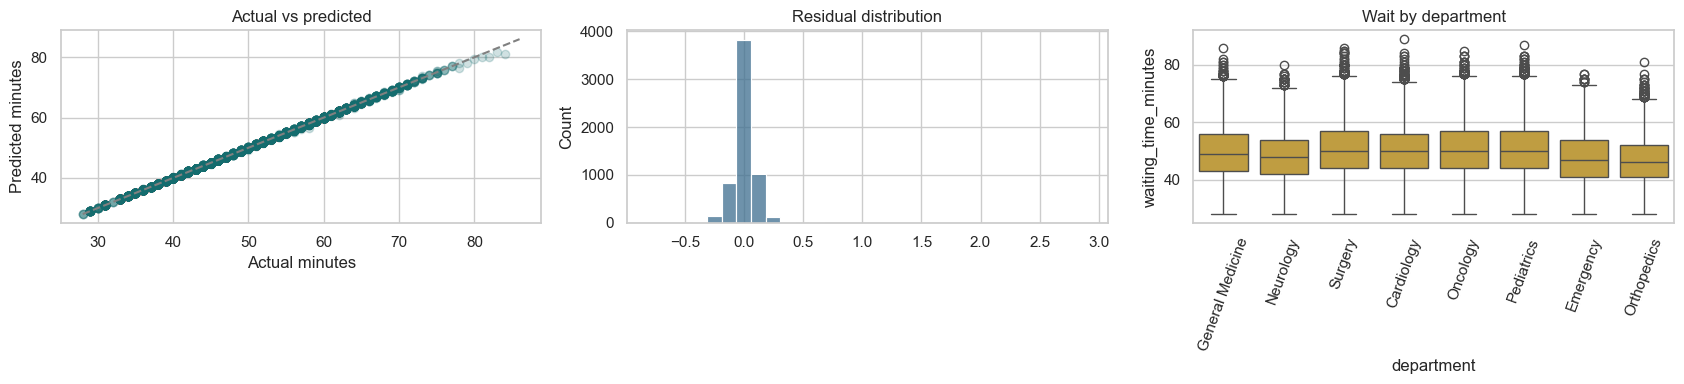

In [5]:
best_name = results.iloc[0]["model"]
best_model = fitted_models[best_name]
best_prediction = predictions[best_name]
residuals = y_test.to_numpy() - best_prediction

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].scatter(y_test, best_prediction, alpha=0.2, color="#146C6E")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "--", color="gray")
axes[0].set_title("Actual vs predicted")
axes[0].set_xlabel("Actual minutes")
axes[0].set_ylabel("Predicted minutes")
sns.histplot(residuals, bins=30, ax=axes[1], color="#3D6E8F")
axes[1].set_title("Residual distribution")
sns.boxplot(
    data=data, x="department", y="waiting_time_minutes",
    ax=axes[2], color="#D4A72C"
)
axes[2].tick_params(axis="x", rotation=70)
axes[2].set_title("Wait by department")
plt.tight_layout()
plt.show()

## 4. Save model and conclusions

In [6]:
joblib.dump(best_model, MODELS / "wait_time_model.pkl")
results.to_csv(REPORTS / "wait_time_notebook_metrics.csv", index=False)
print("Selected:", best_name)
print("Saved:", MODELS / "wait_time_model.pkl")

Selected: lightgbm
Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\models\wait_time_model.pkl


## Business conclusions

- RMSE describes operational variability while MAE is easier for managers to interpret.
- Department load, patient type, ward, complexity, and weekend admission are
  useful queue-planning signals.
- Predictions should trigger staffing review, not promise an exact patient wait.
- Arrival-hour and real roster data would materially improve this model.